In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../..").resolve()))

import pandas as pd
from src.utils.db import get_connection

import ast
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
import datetime
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import seaborn as sns

warnings.filterwarnings('ignore')

# plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

conn = get_connection()

reviews_df = pd.read_sql(
    "SELECT * FROM steam_indie_reviews",
    conn
)

metadata_df = pd.read_sql(
    "SELECT * FROM steam_indie_9692",
    conn
)

df_details = pd.read_sql(
    "SELECT * FROM steam_app_details",
    conn
)

reviews_df['author_playtime_forever'] = reviews_df['author_playtime_forever'].astype('int64')
reviews_df['author_playtime_at_review'] = reviews_df['author_playtime_at_review'].astype('int64')
metadata_df['owners_lower'] = metadata_df['owners_lower'].astype('int64')
metadata_df['positive'] = metadata_df['positive'].astype('int64')
metadata_df['negative'] = metadata_df['negative'].astype('int64')
metadata_df['total_reviews'] = metadata_df['total_reviews'].astype('int64')
reviews_df['timestamp_created'] = reviews_df['timestamp_created'].astype('int64')
reviews_df['timestamp_created'] = reviews_df['timestamp_created'].apply(lambda x: datetime.datetime.fromtimestamp(x))
reviews_df['timestamp_created'] = reviews_df['timestamp_created'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')
reviews_df['timestamp_updated'] = reviews_df['timestamp_updated'].astype('int64')
reviews_df['timestamp_updated'] = reviews_df['timestamp_updated'].apply(lambda x: datetime.datetime.fromtimestamp(x))
reviews_df['timestamp_updated'] = reviews_df['timestamp_updated'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')



conn.close()

In [22]:
df_merge = pd.merge(
    metadata_df,
    df_details[['appid', 'controller_support', 'publishers', 'categories', 'coming_soon', 'windows', 'mac', 'linux', 'recommendations_total', 'achievements_total']],
    on = 'appid'
)

In [12]:
df_merge.dtypes

appid                    int64
name                       str
owners                     str
positive                 int64
negative                 int64
price                    int64
ccu                      int64
genres                     str
release_date               str
developers                 str
total_reviews            int64
owners_lower             int64
is_f2p                     str
is_early_access            str
controller_support         str
publishers                 str
categories                 str
coming_soon                str
windows                    str
mac                        str
linux                      str
recommendations_total      str
achievements_total         str
multi_status               str
dtype: object

In [25]:
df_merge['owners_lower'].value_counts()

owners_lower
0           7122
20000       1189
50000        556
100000       317
200000       233
500000        77
1000000       34
2000000       11
10000000       5
5000000        3
20000000       1
Name: count, dtype: int64

In [3]:
df_merge['windows'] = df_merge['windows'].str.lower().map({'true': True, 'false': False})
df_merge['mac'] = df_merge['mac'].str.lower().map({'true': True, 'false': False})
df_merge['linux'] = df_merge['linux'].str.lower().map({'true': True, 'false': False})

In [24]:
df_merge = df_merge[df_merge['total_reviews'] >= 10]

In [19]:
import pandas as pd
import plotly.express as px

# 1. 멀티플레이 여부 판단 함수
def check_multiplayer(cat_str):
    if pd.isna(cat_str): return "Single-player Only"
    multi_keywords = ['Multi-player', 'Co-op', 'Online Co-op', 'PvP']
    if any(word in cat_str for word in multi_keywords):
        return "Multiplayer/Co-op Supported"
    return "Single-player Only"

df_merge['multi_status'] = df_merge['categories'].apply(check_multiplayer)

# 2. 멀티플레이 여부에 따른 판매량 분포 시각화
fig_multi = px.box(
    df_merge, 
    x='multi_status', 
    y='owners_lower', 
    color='multi_status',
    log_y=True,
    title='멀티플레이 지원 여부에 따른 판매량(Owners) 분포 비교',
    labels={'owners_lower': '판매량 하한선 (Log Scale)', 'multi_status': '지원 여부'},
    color_discrete_map={'Multiplayer/Co-op Supported': '#636EFA', 'Single-player Only': '#FECB52'}
)

fig_multi.update_layout(template="plotly_white", showlegend=False)
fig_multi.show()

# 3. 통계 요약 출력
print(df_merge.groupby('multi_status')['owners_lower'].describe()[['count', '50%', 'mean']])

                              count  50%           mean
multi_status                                           
Multiplayer/Co-op Supported  1432.0  0.0  112576.815642
Single-player Only           8116.0  0.0   18256.530310


In [27]:
import pandas as pd
import plotly.express as px

# 1. 멀티플레이 여부 판단 함수
def check_multiplayer(cat_str):
    if pd.isna(cat_str): return "Single-player Only"
    multi_keywords = ['Multi-player', 'Co-op', 'Online Co-op', 'PvP']
    if any(word in cat_str for word in multi_keywords):
        return "Multiplayer/Co-op Supported"
    return "Single-player Only"

df_merge['multi_status'] = df_merge['categories'].apply(check_multiplayer)

# 2. 멀티플레이 여부에 따른 총 리뷰수 분포 시각화
fig_multi = px.box(
    df_merge, 
    x='multi_status', 
    y='total_reviews', 
    color='multi_status',
    log_y=True,
    title='멀티플레이 지원 여부에 따른 총 리뷰수 분포 비교',
    labels={'total_reviews': '총 리뷰수 (Log Scale)', 'multi_status': '지원 여부'},
    color_discrete_map={'Multiplayer/Co-op Supported': '#636EFA', 'Single-player Only': '#FECB52'}
)

fig_multi.update_layout(template="plotly_white", showlegend=False)
fig_multi.show()

# 3. 통계 요약 출력
print(df_merge.groupby('multi_status')['total_reviews'].describe()[['count', '50%', 'mean']])

                              count   50%         mean
multi_status                                          
Multiplayer/Co-op Supported  1432.0  63.5  2571.170391
Single-player Only           8116.0  38.0   487.482257


In [29]:
import pandas as pd
from scipy import stats

# 1. 멀티플레이 여부 변수 생성 (0: 싱글, 1: 멀티)
multi_keywords = ['Multi-player', 'Co-op', 'Online Co-op', 'PvP', 'Shared/Split Screen']

def check_multi(cat_str):
    if pd.isna(cat_str): return 0
    return 1 if any(word in cat_str for word in multi_keywords) else 0

df_merge['is_multiplayer'] = df_merge['categories'].apply(check_multi)

# 2. 스피어먼 상관계수 및 p-value 계산
# spearmanr은 데이터가 정규분포를 따르지 않거나 순위 기반일 때 적합합니다.
corr_coef, p_value = stats.spearmanr(df_merge['is_multiplayer'], df_merge['owners_lower'])

print(f"--- 상관관계 분석 결과 ---")
print(f"스피어먼 상관계수 (Spearman Rank Correlation): {corr_coef:.4f}")
print(f"유의 확률 (p-value): {p_value:.4e}")

# 3. 결과 해석
if p_value < 0.05:
    print("\n[해석] p-value가 0.05보다 작으므로, 멀티플레이 지원과 판매량 사이에는 통계적으로 유의미한 관계가 있습니다.")
    if corr_coef > 0:
        print("결과적으로 멀티플레이를 지원할수록 판매량이 높아지는 양(+)의 관계를 보입니다.")
else:
    print("\n[해석] p-value가 0.05보다 크므로, 두 변수 사이의 관계가 우연일 가능성을 배제할 수 없습니다.")

--- 상관관계 분석 결과 ---
스피어먼 상관계수 (Spearman Rank Correlation): 0.0906
유의 확률 (p-value): 7.4780e-19

[해석] p-value가 0.05보다 작으므로, 멀티플레이 지원과 판매량 사이에는 통계적으로 유의미한 관계가 있습니다.
결과적으로 멀티플레이를 지원할수록 판매량이 높아지는 양(+)의 관계를 보입니다.


In [28]:
import pandas as pd
from scipy import stats

# 1. 멀티플레이 여부 변수 생성 (0: 싱글, 1: 멀티)
multi_keywords = ['Multi-player', 'Co-op', 'Online Co-op', 'PvP', 'Shared/Split Screen']

def check_multi(cat_str):
    if pd.isna(cat_str): return 0
    return 1 if any(word in cat_str for word in multi_keywords) else 0

df_merge['is_multiplayer'] = df_merge['categories'].apply(check_multi)

# 2. 스피어먼 상관계수 및 p-value 계산
# spearmanr은 데이터가 정규분포를 따르지 않거나 순위 기반일 때 적합합니다.
corr_coef, p_value = stats.spearmanr(df_merge['is_multiplayer'], df_merge['total_reviews'])

print(f"--- 상관관계 분석 결과 ---")
print(f"스피어먼 상관계수 (Spearman Rank Correlation): {corr_coef:.4f}")
print(f"유의 확률 (p-value): {p_value:.4e}")

# 3. 결과 해석
if p_value < 0.05:
    print("\n[해석] p-value가 0.05보다 작으므로, 멀티플레이 지원과 리뷰 수 사이에는 통계적으로 유의미한 관계가 있습니다.")
    if corr_coef > 0:
        print("결과적으로 멀티플레이를 지원할수록 리뷰 수가 높아지는 양(+)의 관계를 보입니다.")
else:
    print("\n[해석] p-value가 0.05보다 크므로, 두 변수 사이의 관계가 우연일 가능성을 배제할 수 없습니다.")

--- 상관관계 분석 결과 ---
스피어먼 상관계수 (Spearman Rank Correlation): 0.1006
유의 확률 (p-value): 6.8192e-23

[해석] p-value가 0.05보다 작으므로, 멀티플레이 지원과 리뷰 수 사이에는 통계적으로 유의미한 관계가 있습니다.
결과적으로 멀티플레이를 지원할수록 리뷰 수가 높아지는 양(+)의 관계를 보입니다.


In [63]:
df_merge[df_merge['genres'] == "['Indie']"]

,appid,name,owners,positive,negative,price,ccu,genres,release_date,developers,...,linux,recommendations_total,achievements_total,multi_status,is_multiplayer,genres_list,controller_status,platform_count,has_controller,genres_split
160,2166060,Amanda the Adventurer,"200,000 .. 500,000",5993,391,899,27,['Indie'],2023-04-25,MANGLEDmaw Games,...,false,5789,19,Single-player Only,0,[Indie],None / KB+M Only,truefalsefalse,0,[['Indie']]
228,2429860,Living With Sister: Monochrome Fantasy,"200,000 .. 500,000",10033,361,1039,226,['Indie'],2024-03-22,Inusuku,...,false,11268,NaN,Single-player Only,0,[Indie],None / KB+M Only,truefalsefalse,0,[['Indie']]
308,2832560,Silent,"200,000 .. 500,000",12,14,299,0,['Indie'],2024-11-21,GenemesicX,...,false,NaN,NaN,Single-player Only,0,[Indie],None / KB+M Only,truefalsefalse,0,[['Indie']]
317,2394440,The Great Below,"200,000 .. 500,000",29,1,499,0,['Indie'],2023-12-05,Dobra Studios,...,false,NaN,9,Single-player Only,0,[Indie],Full Support,truefalsefalse,1,[['Indie']]
354,2235240,TaskPals,"200,000 .. 500,000",998,86,299,26,['Indie'],2023-05-25,Ascalon Games,...,false,NaN,NaN,Single-player Only,0,[Indie],None / KB+M Only,truefalsefalse,0,[['Indie']]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9429,3615590,My Life as a Robot Vacuum,"0 .. 20,000",18,0,299,0,['Indie'],2025-05-02,Lord Soul Studios,...,false,NaN,5,Single-player Only,0,[Indie],None / KB+M Only,truefalsefalse,0,[['Indie']]
9438,2957270,Three Bulky Bears,"0 .. 20,000",16,0,999,0,['Indie'],2025-03-31,Storytime Games,...,true,NaN,16,Single-player Only,0,[Indie],Full Support,truefalsetrue,1,[['Indie']]
9479,649960,Happy Lab,"0 .. 20,000",29,2,499,0,['Indie'],2023-10-26,"Sunset TEKO, Badim",...,false,NaN,38,Single-player Only,0,[Indie],Full Support,truefalsefalse,1,[['Indie']]
9514,1045900,Outpost On Syrinx,"0 .. 20,000",17,4,1999,0,['Indie'],2024-04-29,Polychrome Games,...,false,NaN,NaN,Single-player Only,0,[Indie],None / KB+M Only,truefalsefalse,0,[['Indie']]


In [16]:
# 1. 장르 확장 및 멀티플레이 상태 병합
df_merge['genres_list'] = df_merge['genres'].apply(ast.literal_eval)
df_genre_multi = df_merge.explode('genres_list')

# 주요 5대 장르만 필터링
top_5_genres = ["Action", "RPG", "Adventure", "Simulation", "Strategy"]
df_genre_multi = df_genre_multi[df_genre_multi['genres_list'].isin(top_5_genres)]

# 2. 장르 & 멀티 여부별 판매량 중앙값 계산
genre_multi_stats = df_genre_multi.groupby(['genres_list', 'multi_status'])['owners_lower'].median().reset_index()

In [32]:
genre_multi_stats

,genres_list,multi_status,owners_lower
0,Action,Multiplayer/Co-op Supported,0.0
1,Action,Single-player Only,0.0
2,Adventure,Multiplayer/Co-op Supported,0.0
3,Adventure,Single-player Only,0.0
4,RPG,Multiplayer/Co-op Supported,0.0
5,RPG,Single-player Only,0.0
6,Simulation,Multiplayer/Co-op Supported,0.0
7,Simulation,Single-player Only,0.0
8,Strategy,Multiplayer/Co-op Supported,0.0
9,Strategy,Single-player Only,0.0


In [33]:
# 3. 시각화 (Grouped Bar Chart)
fig_synergy = px.bar(
    genre_multi_stats, 
    x='genres_list', 
    y='owners_lower', 
    color='multi_status',
    barmode='group',
    title='장르별 멀티플레이 지원에 따른 판매량(Owners) 차이',
    labels={'owners_lower': '판매량 하한선 (중앙값)', 'genres_list': '장르', 'multi_status': '멀티 지원 여부'},
    color_discrete_map={'Multiplayer/Co-op Supported': '#636EFA', 'Single-player Only': '#FECB52'}
)

fig_synergy.update_layout(template="plotly_white")
fig_synergy.show()

### 판매량 하한선이 0인 데이터가 너무 많음...

In [35]:
# 1. 장르 확장 및 멀티플레이 상태 병합
df_merge['genres_list'] = df_merge['genres'].apply(ast.literal_eval)
df_genre_multi = df_merge.explode('genres_list')

# 주요 5대 장르만 필터링
top_5_genres = ["Action", "RPG", "Adventure", "Simulation", "Strategy"]
df_genre_multi = df_genre_multi[df_genre_multi['genres_list'].isin(top_5_genres)]

# 2. 장르 & 멀티 여부별 총 리뷰수 중앙값 계산
genre_multi_stats = df_genre_multi.groupby(['genres_list', 'multi_status'])['total_reviews'].median().reset_index()

In [36]:
genre_multi_stats

,genres_list,multi_status,total_reviews
0,Action,Multiplayer/Co-op Supported,70.0
1,Action,Single-player Only,33.0
2,Adventure,Multiplayer/Co-op Supported,95.0
3,Adventure,Single-player Only,40.0
4,RPG,Multiplayer/Co-op Supported,158.0
5,RPG,Single-player Only,64.0
6,Simulation,Multiplayer/Co-op Supported,125.0
7,Simulation,Single-player Only,51.0
8,Strategy,Multiplayer/Co-op Supported,68.0
9,Strategy,Single-player Only,50.5


In [38]:
# 3. 시각화 (Grouped Bar Chart)
fig_synergy = px.bar(
    genre_multi_stats, 
    x='genres_list', 
    y='total_reviews', 
    color='multi_status',
    barmode='group',
    title='장르별 멀티플레이 지원에 따른 총 리뷰수 차이',
    labels={'owners_lower': '총 리뷰수 (중앙값)', 'genres_list': '장르', 'multi_status': '멀티 지원 여부'},
    color_discrete_map={'Multiplayer/Co-op Supported': '#636EFA', 'Single-player Only': '#FECB52'}
)

fig_synergy.update_layout(template="plotly_white")
fig_synergy.show()

In [39]:
# 1. 컨트롤러 지원 상태 세분화 함수
def get_controller_status(row):
    cat = str(row['categories'])
    support = str(row['controller_support'])
    # 'Full' 지원 키워드 확인
    if 'Full controller support' in cat or 'full' in support.lower():
        return 'Full Support'
    # 'Partial' 지원 키워드 확인
    elif 'Partial Controller Support' in cat:
        return 'Partial Support'
    else:
        return 'None / KB+M Only'

In [40]:
# 3. 플랫폼(OS) 지원 개수 계산 (Windows, Mac, Linux)
df_merge['controller_status'] = df_merge.apply(get_controller_status, axis=1)
df_merge['platform_count'] = df_merge[['windows', 'mac', 'linux']].sum(axis=1)

# 4. 분석 데이터 집계 (중앙값 기준)
ctrl_stats = df_merge.groupby('controller_status')['owners_lower'].median().reset_index()
plat_stats = df_merge.groupby('platform_count')['owners_lower'].median().reset_index()

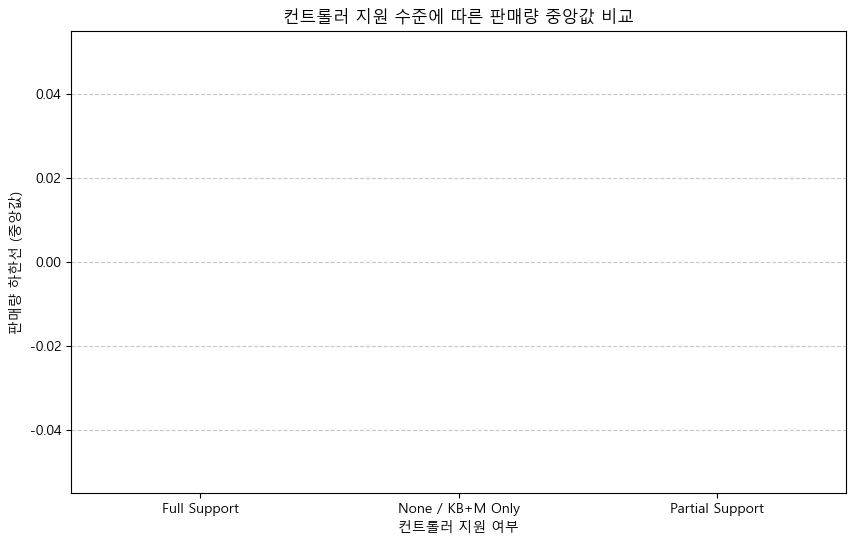

In [41]:
# 5. 시각화 1: 컨트롤러 지원 수준별 판매량
plt.figure(figsize=(10, 6))
sns.barplot(data=ctrl_stats, x='controller_status', y='owners_lower', palette='coolwarm')
plt.title('컨트롤러 지원 수준에 따른 판매량 중앙값 비교')
plt.ylabel('판매량 하한선 (중앙값)')
plt.xlabel('컨트롤러 지원 여부')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [42]:
# 3. 플랫폼(OS) 지원 개수 계산 (Windows, Mac, Linux)
df_merge['controller_status'] = df_merge.apply(get_controller_status, axis=1)
df_merge['platform_count'] = df_merge[['windows', 'mac', 'linux']].sum(axis=1)

# 4. 분석 데이터 집계 (중앙값 기준)
ctrl_stats = df_merge.groupby('controller_status')['total_reviews'].median().reset_index()
plat_stats = df_merge.groupby('platform_count')['total_reviews'].median().reset_index()

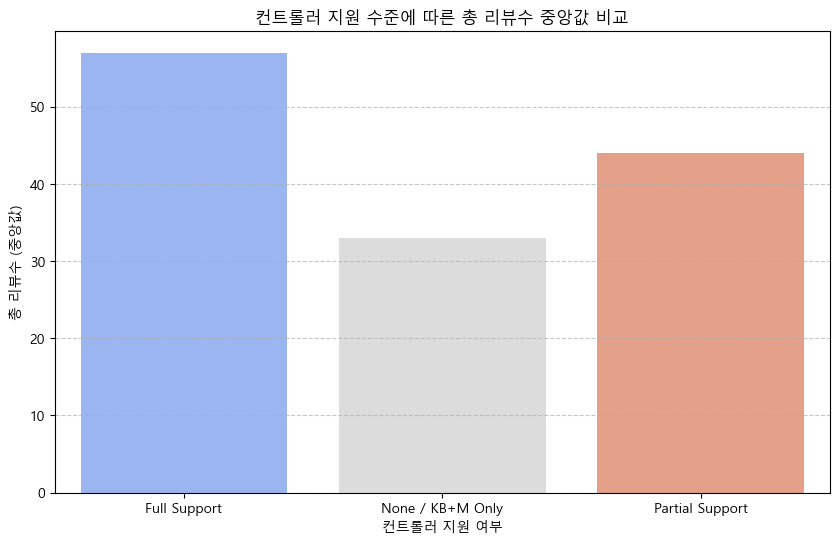

In [43]:
# 5. 시각화 1: 컨트롤러 지원 수준별 판매량
plt.figure(figsize=(10, 6))
sns.barplot(data=ctrl_stats, x='controller_status', y='total_reviews', palette='coolwarm')
plt.title('컨트롤러 지원 수준에 따른 총 리뷰수 중앙값 비교')
plt.ylabel('총 리뷰수 (중앙값)')
plt.xlabel('컨트롤러 지원 여부')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

,appid,name,owners,positive,negative,price,ccu,genres,release_date,developers,total_reviews,owners_lower,is_f2p,is_early_access


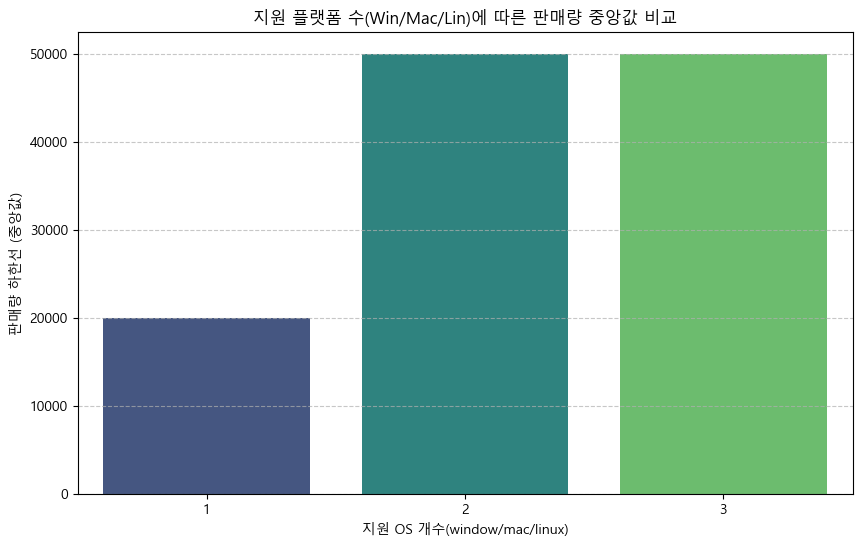

In [12]:
# 6. 시각화 2: 지원 플랫폼 수에 따른 판매량
plt.figure(figsize=(10, 6))
sns.barplot(data=plat_stats, x='platform_count', y='owners_lower', palette='viridis')
plt.title('지원 플랫폼 수(Win/Mac/Lin)에 따른 판매량 중앙값 비교')
plt.ylabel('판매량 하한선 (중앙값)')
plt.xlabel('지원 OS 개수(window/mac/linux)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

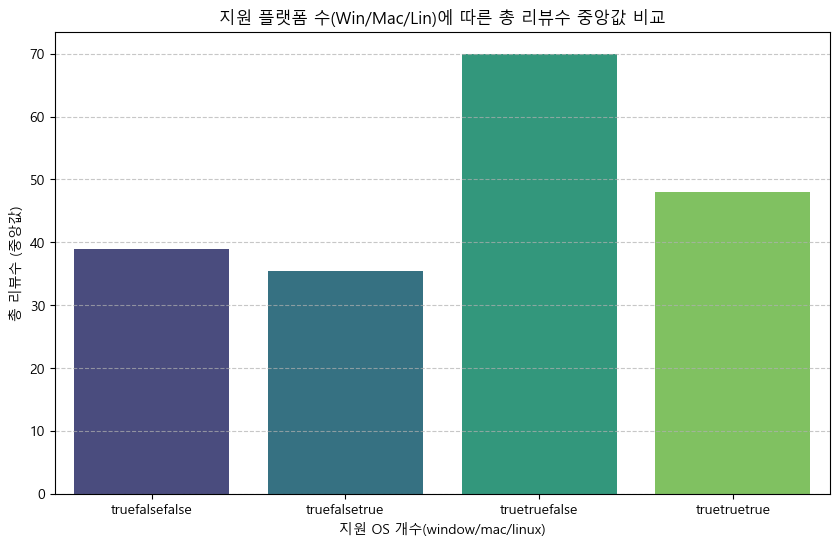

In [45]:
# 6. 시각화 2: 지원 플랫폼 수에 따른 판매량
plt.figure(figsize=(10, 6))
sns.barplot(data=plat_stats, x='platform_count', y='total_reviews', palette='viridis')
plt.title('지원 플랫폼 수(Win/Mac/Lin)에 따른 총 리뷰수 중앙값 비교')
plt.ylabel('총 리뷰수 (중앙값)')
plt.xlabel('지원 OS 개수(window/mac/linux)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [46]:
# 1. 컨트롤러 지원 여부 판단 (Full 또는 Partial 포함)
def check_controller(row):
    cat = str(row['categories'])
    support = str(row['controller_support'])
    if 'controller' in cat.lower() or 'full' in support.lower() or 'partial' in support.lower():
        return 1
    return 0

In [66]:
df_merge['has_controller'] = df_merge.apply(check_controller, axis=1)

# 2. 장르 파싱 및 데이터 확장
# 'Action, Indie' 형태의 문자열을 분리하여 각 행으로 만듭니다.
df_merge['genres_split'] = df_merge['genres'].str.split(', ')
df_genre = df_merge.explode('genres_split')
# 특수문자 제거 및 공백 정리
df_genre['genres_split'] = df_genre['genres_split'].str.replace(r"[\[\]']", "", regex=True).str.strip()
# 장르별 데이터 개수가 10개 이상인 그룹만 남기기
df_genre = df_genre.groupby('genres_split').filter(lambda x: len(x) >= 10)

# 3. 장르별 지원율 계산
genre_rate = df_genre.groupby('genres_split')['has_controller'].mean().sort_values(ascending=False) * 100

In [70]:
genre_rate = genre_rate.drop(['Indie'])

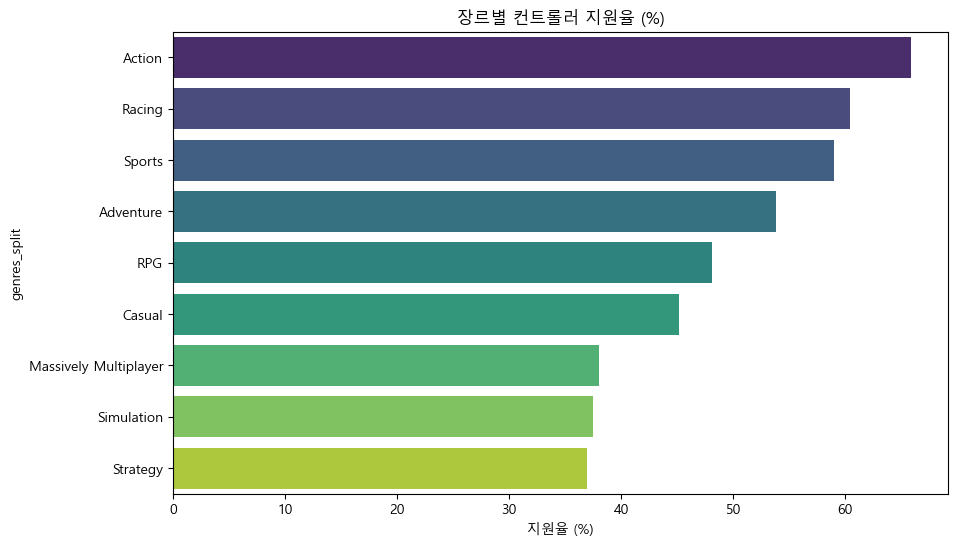

In [71]:
# 4. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_rate.values, y=genre_rate.index, palette='viridis')
plt.title('장르별 컨트롤러 지원율 (%)')
plt.xlabel('지원율 (%)')
plt.show()

In [72]:
# 데이터 수가 너무 적은 장르는 제외 (최소 10개 이상인 장르만 필터링)
genre_counts = df_genre['genres_split'].value_counts()
top_genres = genre_counts[genre_counts >= 10].index
df_filtered = df_genre[df_genre['genres_split'].isin(top_genres)]

# 4. 장르 및 지원 여부별 판매량 중앙값 집계
# 중앙값(Median)을 사용하는 이유는 초대박 게임에 의한 평균 왜곡을 방지하기 위함입니다.
sales_impact = df_filtered.groupby(['genres_split', 'controller_status'])['owners_lower'].median().reset_index()

In [73]:
sales_impact

,genres_split,controller_status,owners_lower
0,Action,Full Support,0.0
1,Action,None / KB+M Only,0.0
2,Action,Partial Support,0.0
3,Adventure,Full Support,0.0
4,Adventure,None / KB+M Only,0.0
5,Adventure,Partial Support,0.0
6,Casual,Full Support,0.0
7,Casual,None / KB+M Only,0.0
8,Casual,Partial Support,0.0
9,Indie,Full Support,0.0


In [74]:
# 데이터 수가 너무 적은 장르는 제외 (최소 10개 이상인 장르만 필터링)
genre_counts = df_genre['genres_split'].value_counts()
top_genres = genre_counts[genre_counts >= 10].index
df_filtered = df_genre[df_genre['genres_split'].isin(top_genres)]

# 4. 장르 및 지원 여부별 총 리뷰 수 중앙값 집계
# 중앙값(Median)을 사용하는 이유는 초대박 게임에 의한 평균 왜곡을 방지하기 위함입니다.
sales_impact = df_filtered.groupby(['genres_split', 'controller_status'])['total_reviews'].median().reset_index()

In [75]:
sales_impact = sales_impact[sales_impact['genres_split'] != 'Indie']

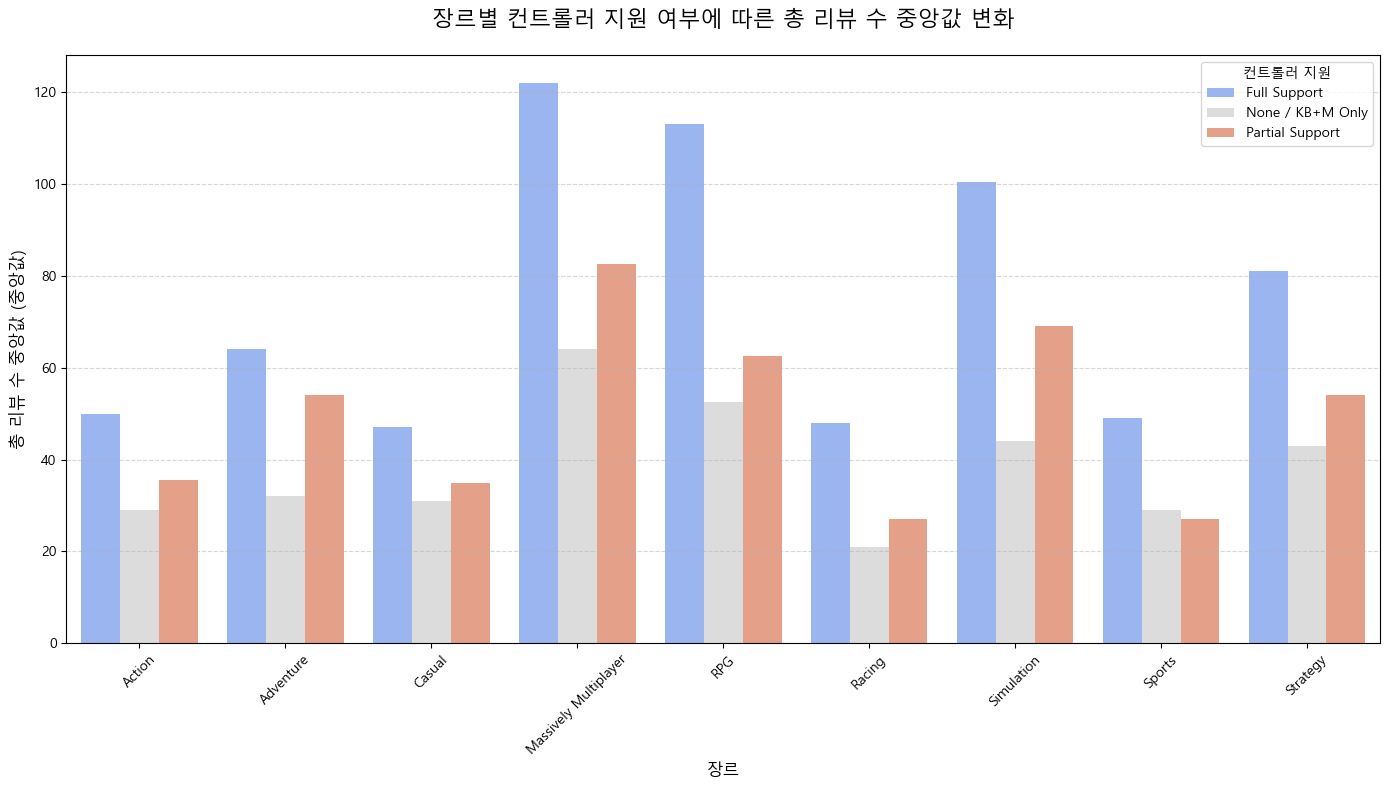

In [78]:
# 5. 시각화 (Grouped Bar Chart)
plt.figure(figsize=(14, 8))

sns.barplot(data=sales_impact, x='genres_split', y='total_reviews', hue='controller_status', palette='coolwarm')

plt.title('장르별 컨트롤러 지원 여부에 따른 총 리뷰 수 중앙값 변화', fontsize=16, pad=20)
plt.xlabel('장르', fontsize=12)
plt.ylabel('총 리뷰 수 중앙값 (중앙값)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='컨트롤러 지원', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [79]:
# 2. 컨트롤러 지원 여부 이진화
def check_controller(row):
    cat = str(row['categories'])
    support = str(row['controller_support'])
    if 'controller' in cat.lower() or 'full' in support.lower() or 'partial' in support.lower():
        return 'Supported'
    return 'Not Supported'

df_check = df_merge.copy()

df_check['controller_status'] = df_check.apply(check_controller, axis=1)

In [29]:
# 1. 그룹 분리
group_supported = df_check[df_check['controller_status'] == 'Supported']['owners_lower']
group_not_supported = df_check[df_check['controller_status'] == 'Not Supported']['owners_lower']

# 2. 맨-휘트니 U 검정 수행
# H0 (귀무가설): 두 그룹의 판매량 분포는 차이가 없다.
# H1 (대립가설): 두 그룹의 판매량 분포에는 유의미한 차이가 있다.
u_stat, p_value = stats.mannwhitneyu(group_supported, group_not_supported, alternative='two-sided')

# 3. 결과 출력
print(f"지원 그룹 판매량 중앙값: {group_supported.median():,.0f}")
print(f"미지원 그룹 판매량 중앙값: {group_not_supported.median():,.0f}")
print(f"p-value: {p_value:.4f}")

지원 그룹 판매량 중앙값: 50,000
미지원 그룹 판매량 중앙값: 20,000
p-value: 0.1323


In [81]:
# 1. 그룹 분리
group_supported = df_check[df_check['controller_status'] == 'Supported']['total_reviews']
group_not_supported = df_check[df_check['controller_status'] == 'Not Supported']['total_reviews']

# 2. 맨-휘트니 U 검정 수행
# H0 (귀무가설): 두 그룹의 총 리뷰수 분포는 차이가 없다.
# H1 (대립가설): 두 그룹의 총 리뷰수 분포에는 유의미한 차이가 있다.
u_stat, p_value = stats.mannwhitneyu(group_supported, group_not_supported, alternative='two-sided')

# 3. 결과 출력
print(f"지원 그룹 총 리뷰수 중앙값: {group_supported.median():,.0f}")
print(f"미지원 그룹 총 리뷰수 중앙값: {group_not_supported.median():,.0f}")
print(f"p-value: {p_value:.4f}")

지원 그룹 총 리뷰수 중앙값: 54
미지원 그룹 총 리뷰수 중앙값: 33
p-value: 0.0000


In [17]:
df_merge['recommendations_total'] = df_merge['recommendations_total'].apply(pd.to_numeric, errors = 'coerce')
df_merge[['positive', 'recommendations_total']]

,positive,recommendations_total
0,18523,21369.0
1,7849,9269.0
2,2355,2846.0
3,108883,117968.0
4,15988,22876.0
...,...,...
153,19,NaN
154,11,NaN
155,13,NaN
156,8,NaN


In [23]:
df_test = df_merge[df_merge['recommendations_total'].notna()]
df_test['recommendations_total'].isna().sum()

np.int64(0)

In [24]:
df_test[df_test['recommendations_total'] < df_test['positive']]

,appid,name_store,release_date,genres,owners,owners_lower,positive,negative,total_reviews,price_spy,...,is_f2p,controller_support,publishers,categories,coming_soon,windows,mac,linux,recommendations_total,achievements_total
6,1948800,Yi Xian: The Cultivation Card Game,2024-01-21,"['Casual', 'Indie', 'Strategy', 'Free To Play']","500,000 .. 1,000,000",500000,4531,1601,6132,0,...,True,NaN,Gamirror Games,"Single-player, Multi-player, PvP, Online PvP, ...",false,true,true,true,4029.0,36.0
17,1049590,Eternal Return,2023-07-19,"['Indie', 'Strategy', 'Free To Play']","5,000,000 .. 10,000,000",5000000,51694,13352,65046,0,...,True,NaN,"Nimble Neuron, SapStaR Games","Multi-player, PvP, Online PvP, Steam Trading C...",false,true,false,false,107.0,0.0
22,1507580,Enigma of Fear,2024-11-28,"['Action', 'Adventure', 'Indie']","200,000 .. 500,000",200000,8803,290,9093,1949,...,False,full,"Dumativa, CriticalLeap","Single-player, Steam Achievements, Full contro...",false,true,false,false,2923.0,19.0
30,2457580,Fight Crab 2,2024-02-13,"['Action', 'Indie', 'Sports', 'Early Access']","200,000 .. 500,000",200000,130,7,137,1499,...,False,NaN,PLAYISM,"Single-player, Multi-player, PvP, Online PvP, ...",false,true,false,false,122.0,0.0
63,2715370,Ancient Cultivatrix,2025-02-13,"['Indie', 'RPG', 'Strategy']","20,000 .. 50,000",20000,287,96,383,899,...,False,NaN,五条虾仁(5 shrimps),"Single-player, Steam Achievements, Steam Cloud...",false,true,false,false,240.0,91.0
95,1785120,Forsake: Urban horror,2023-03-31,['Indie'],"20,000 .. 50,000",20000,173,42,215,999,...,False,NaN,Unseen Interactive,"Single-player, Multi-player, Co-op, Online Co-...",false,true,false,false,154.0,32.0


In [29]:
df_merge['stratum'].value_counts()

stratum
large_high    29
mid_high      25
mid_mid       20
small_high    20
large_mid     15
small_mid     15
small_low     14
large_low     10
mid_low       10
Name: count, dtype: int64

In [25]:
# 1. 데이터 전처리
df_clean = df_merge.dropna(subset=['recommendations_total']).copy()

# 2. 추천 수 구간화 (Binning)
# qcut을 사용하여 데이터 개수가 균등하게 4구간으로 나눕니다.
df_clean['rec_grade'] = pd.qcut(
    df_clean['recommendations_total'], 
    q=4, 
    labels=['Low', 'Medium', 'High', 'Top']
)

# 3. Stratum x 추천 등급 교차 분석
# 각 판매량 체급별로 추천 등급의 비중(%)을 계산합니다.
cross_tab = pd.crosstab(df_clean['stratum'], df_clean['rec_grade'], normalize='index') * 100

In [30]:
df_clean['stratum'].value_counts()

stratum
large_high    28
mid_high      24
small_high    18
mid_mid       14
large_mid     10
small_mid     10
Name: count, dtype: int64

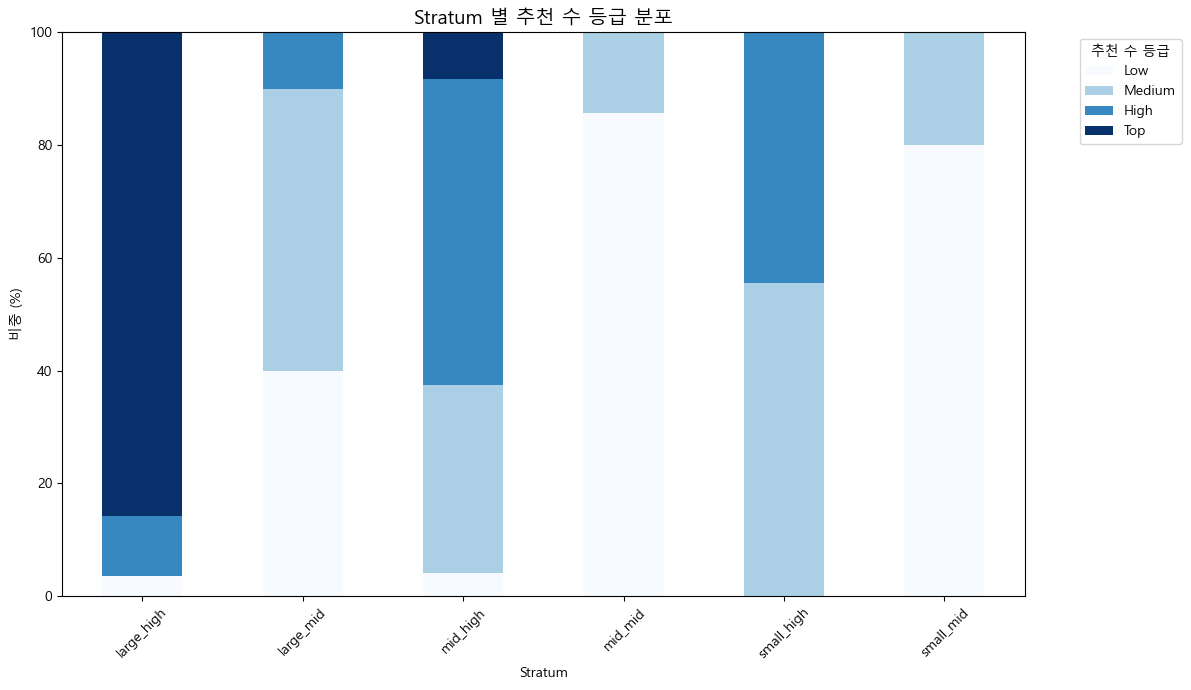

--- Stratum별 추천 수 등급 분포 (%) ---
rec_grade     Low  Medium   High    Top
stratum                                
large_high   3.57    0.00  10.71  85.71
large_mid   40.00   50.00  10.00   0.00
mid_high     4.17   33.33  54.17   8.33
mid_mid     85.71   14.29   0.00   0.00
small_high   0.00   55.56  44.44   0.00
small_mid   80.00   20.00   0.00   0.00


In [28]:
# 4. 시각화 (누적 막대 그래프)
cross_tab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='Blues')

plt.title('Stratum 별 추천 수 등급 분포', fontsize=14)
plt.ylabel('비중 (%)')
plt.xlabel('Stratum')
plt.legend(title='추천 수 등급', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. 수치 데이터 출력
print("--- Stratum별 추천 수 등급 분포 (%) ---")
print(cross_tab.round(2))